<a href="https://colab.research.google.com/github/jiissung/ECON3916-Statistical-Machine-Learning/blob/main/Class%2011/Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

url = 'messy_hr_economics.csv'
df = pd.read_csv("messy_hr_economics.csv")
df

,employee_id,department_raw,department,office_zip,tenure_years,age,year_hired,regional_unemployment,regional_cpi_inflation,performance_rating,bonus_pay,base_salary,retention_risk
0,E100000,Sls,Sales,91586,2.3,27,2024,4.30,3.54,3.0,3571.89,64113.01,0.275
1,E100001,ENG.,Engineering,70260,2.2,38,2024,3.52,3.95,4.5,9351.25,113883.39,0.196
2,E100002,Sales,Sales,33731,1.2,44,2025,4.38,0.70,2.5,3046.72,NaN,0.333
3,E100003,SLS.,Sales,62903,3.2,31,2023,6.59,3.10,NaN,NaN,58762.73,0.222
4,E100004,ENG.,Engineering,85512,7.6,40,2019,6.33,2.99,3.5,8669.21,108171.29,0.189
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,E103195,ENGINEERING,Engineering,90018,6.5,44,2020,6.48,2.83,4.5,3379.95,114435.22,0.174
3196,E103196,mArketing,Marketing,19729,3.4,27,2023,4.85,4.64,3.0,5072.76,NaN,0.184
3197,E103197,Engineering,Engineering,30471,8.3,33,2018,5.80,4.64,5.0,11164.54,130258.13,0.143
3198,E103198,engineerING,Engineering,61123,3.6,42,2023,7.18,3.02,4.0,521.85,NaN,0.115


<Axes: >

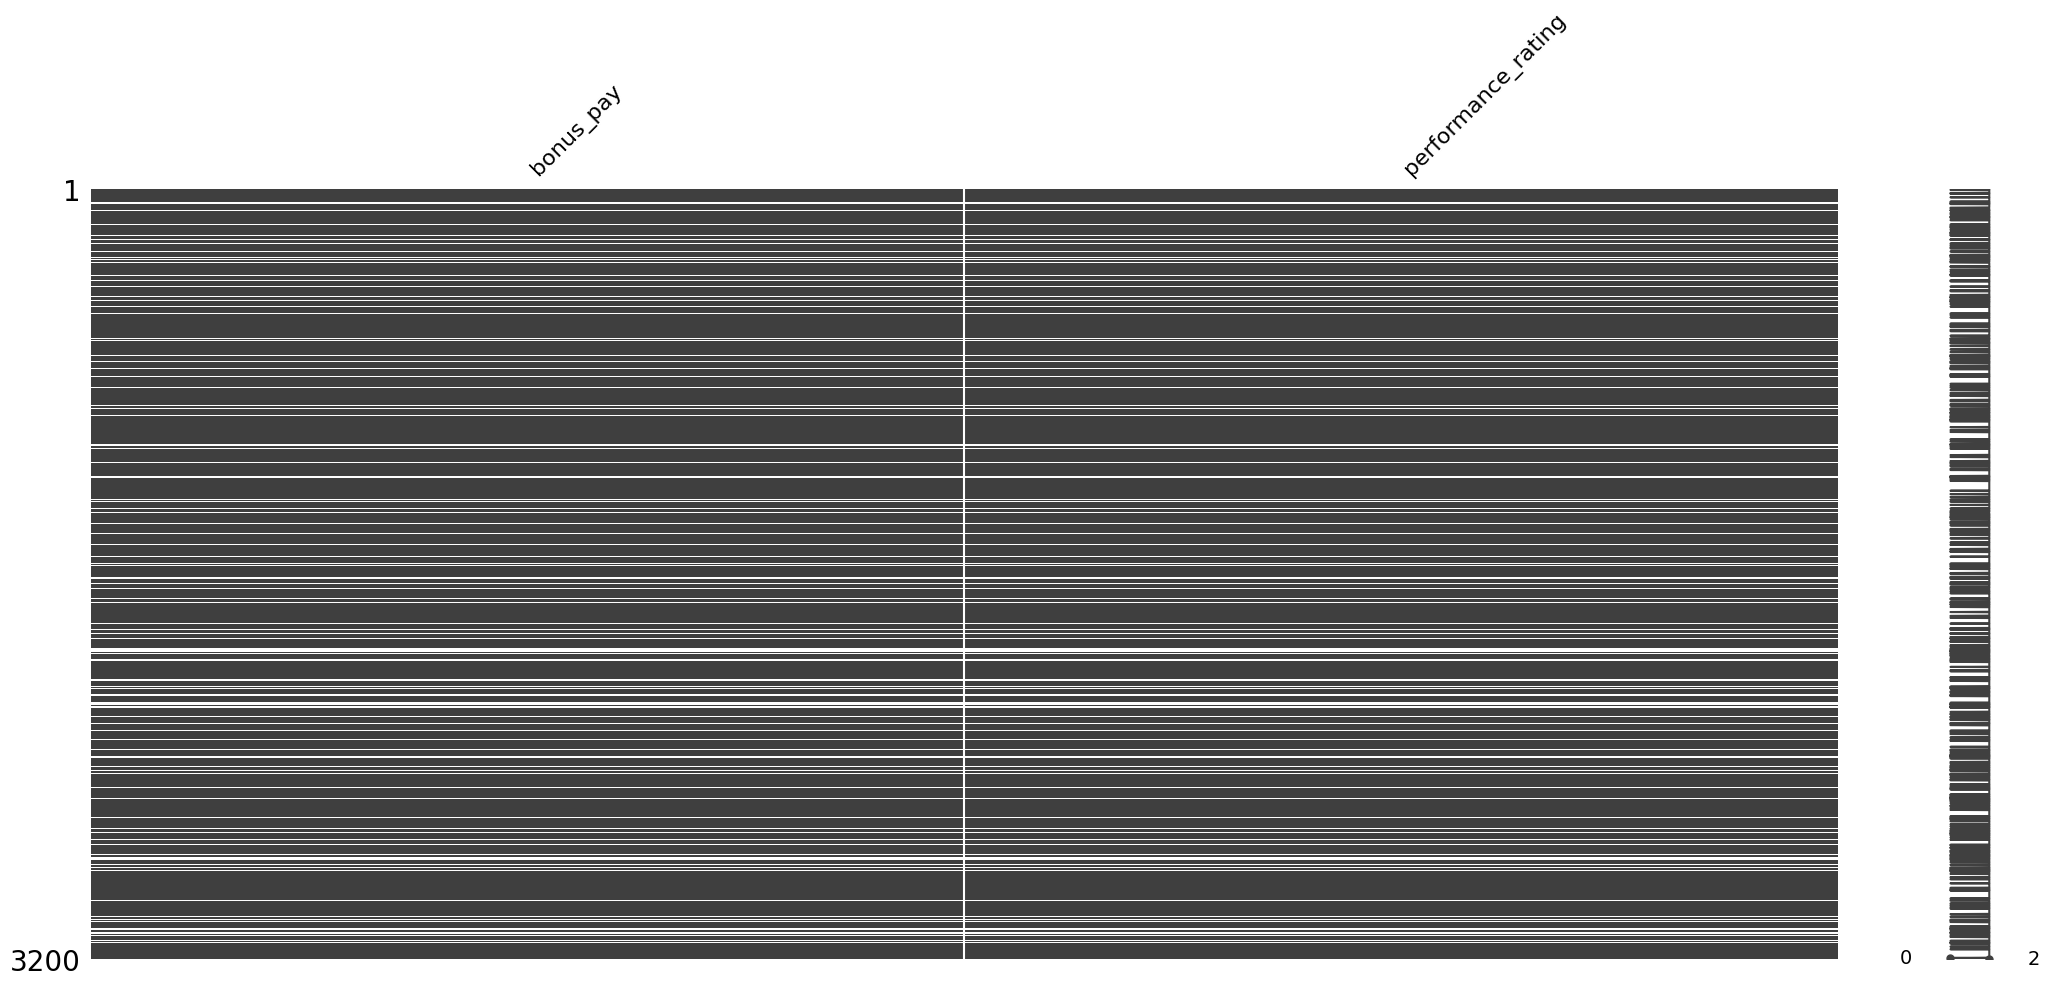

In [15]:
# Step 2:

msno.matrix(df[['bonus_pay', 'performance_rating']])

The white lines are data points that are missing in the dataset. Both variables the same observations missing data.

In [16]:
# Step 3:

df['base_salary'] = df.groupby('department')['base_salary'].transform(lambda x: x.fillna(x.median()))


In [17]:
# Step 4:
dummies_trap = pd.get_dummies(df['department']).astype(int)
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)

X_trap = sm.add_constant(X_trap)
y = df['base_salary']

model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:57:29   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.765e+04    244.020    236.246   

In [18]:
# Step 5

dummies_safe = pd.get_dummies(df['department']).astype(int)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Condensing 800 ZIP codes into a single continuous vector representing average salary
encoder = ce.TargetEncoder()
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:57:29   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.765e+04    244.020    236.246   

In [20]:
# app.py

import streamlit as st
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

st.title("Missing Data Diagnostic & Conditional Imputation")

# ---------------------------------------------------
# Streamlit Caching
# ---------------------------------------------------
# @st.cache_data stores the output of this function so it does not
# re-run every time the Streamlit script refreshes.
# If the same file is uploaded again, Streamlit loads the cached
# dataframe instead of re-reading the CSV, which makes the app faster.
@st.cache_data
def load_data(uploaded_file):
    df = pd.read_csv(uploaded_file)
    return df


# ---------------------------------------------------
# File Upload
# ---------------------------------------------------
uploaded_file = st.file_uploader("Upload a CSV dataset", type=["csv"])

if uploaded_file is not None:

    df = load_data("messy_hr_economics.csv")

    # ---------------------------------------------------
    # Session State
    # ---------------------------------------------------
    # st.session_state stores variables that persist across
    # Streamlit reruns (which happen every time a widget changes).
    #
    # Without session_state, the dataframe would reset every time
    # a user presses a button or changes a dropdown.
    #
    # Here we store the dataset so imputation updates remain visible.
    if "data" not in st.session_state:
        st.session_state.data = df

    st.subheader("Preview of Dataset")
    st.dataframe(st.session_state.data.head())

    st.write("Dataset Shape:", st.session_state.data.shape)

    # ---------------------------------------------------
    # Missingness Matrix Visualization
    # ---------------------------------------------------
    st.subheader("Missingness Matrix")

    fig, ax = plt.subplots()
    msno.matrix(st.session_state.data, ax=ax)
    st.pyplot(fig)

    # ---------------------------------------------------
    # Column Selection for Conditional Imputation
    # ---------------------------------------------------
    st.subheader("Conditional Median Imputation")

    columns = st.session_state.data.columns.tolist()

    target_col = st.selectbox(
        "Select column with missing values to impute",
        columns
    )

    group_col = st.selectbox(
        "Select grouping column (for conditional median)",
        columns
    )

    # ---------------------------------------------------
    # Imputation Button
    # ---------------------------------------------------
    if st.button("Run Conditional Median Imputation"):

        df = st.session_state.data.copy()

        # Calculate conditional medians
        medians = df.groupby(group_col)[target_col].transform("median")

        # Fill missing values
        df[target_col] = df[target_col].fillna(medians)

        # Update session state so results persist
        st.session_state.data = df

        st.success("Imputation completed.")

        st.write("Updated Data Preview")
        st.dataframe(df.head())

    # ---------------------------------------------------
    # Download Option
    # ---------------------------------------------------
    st.subheader("Download Cleaned Dataset")

    csv = st.session_state.data.to_csv(index=False)

    st.download_button(
        label="Download CSV",
        data=csv,
        file_name="imputed_dataset.csv",
        mime="text/csv"
    )

2026-03-13 01:20:11.301 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 01:20:11.522 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-13 01:20:11.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 01:20:11.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 01:20:11.526 No runtime found, using MemoryCacheStorageManager
2026-03-13 01:20:11.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 01:20:11.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-13 01:20:11.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored 